In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.style.use("fivethirtyeight")

In [4]:
df = pd.read_csv("Rainfall.csv")

In [5]:
df

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [6]:
df['rainfall'].unique()

array(['yes', 'no'], dtype=object)

In [7]:
df.shape

(366, 12)

MACHINE LEARNING MODEL --> MLFlow --> FLASK

In [8]:
df['day'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,366.0,15.756831,8.823592,1.0,8.000,16.00,23.000,31.0
pressure,366.0,1013.742623,6.414776,998.5,1008.500,1013.00,1018.100,1034.6
maxtemp,366.0,26.191257,5.978343,7.1,21.200,27.75,31.200,36.3
temparature,366.0,23.747268,5.632813,4.9,18.825,25.45,28.600,32.4
mintemp,366.0,21.894536,5.594153,3.1,17.125,23.70,26.575,30.0
dewpoint,366.0,19.989071,5.997021,-0.4,16.125,21.95,25.000,26.7
humidity,366.0,80.177596,10.062470,36.0,75.000,80.50,87.000,98.0
cloud,366.0,71.128415,21.798012,0.0,58.000,80.00,88.000,100.0
sunshine,366.0,4.419399,3.934398,0.0,0.500,3.50,8.200,12.1
winddirection,365.0,101.506849,81.723724,10.0,40.000,70.00,190.000,350.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [11]:
df.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [12]:
df.columns = df.columns.str.strip()

In [13]:
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [14]:
df = df.drop(columns=['day'])

In [15]:
df.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [16]:
df.isnull().sum()

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64

In [17]:
df['winddirection'].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [18]:
df['windspeed'].unique()

array([26.3, 15.3, 14.2, 16.9, 13.7, 14.5, 21.5, 14.3, 39.3, 37.7, 23.3,
       23.9, 24.4, 33.2, 37.5, 40. , 23.4, 28.4, 38. , 50.6, 26.2, 35.3,
       55.5, 59.5, 28.7, 21.3, 29.6, 28.8, 25. , 21.2, 43.1, 31.9, 27.3,
        9.1, 44.7, 20.5, 16.7, 17.2, 22. , 15.8, 13.9, 10.2, 33.5, 23.5,
       19.2, 18.6, 22.2, 19.3, 28. , 20.4, 15.2,  9.2, 34.2, 27.1, 14.7,
       15.4, 13.3,  6.6, 13.8, 15.1, 39.7, 36. , 22.8, 26.7, 26.5, 13.1,
       12.5, 38.3, 42. , 19.4, 13.4, 14.6, 26.9, 14.8,  4.5,  8.3,  8. ,
       20. , 10. , 17.3, 31.8, 29.8, 11.2, 16. , 19.6, 20.9,  7.3, 11.1,
       13. ,  8.5, 24.2, 20.2, 30.5, 27. , 23.7, 11.8, 15.5, 12.1,  9.5,
       16.3, 12. , 26. , 28.6, 24.9, 28.3, 15.7, 21.9, 39.5, 30.3, 26.4,
       22.3, 25.9, 11.3,  7.9,  7.4, 16.2, 34.8, 32.5, 24. , 19. , 25.2,
       31.7, 27.4, 20.8,  9.8, 12.6,  nan, 24.3, 30. , 29.3, 23.2, 12.8,
       19.8, 12.4, 10.9,  9.6,  9. , 11.9, 26.1, 25.1, 33. , 22.5, 24.8,
       18.8, 22.4, 22.6, 12.3, 21.6, 17.5, 16.1, 14

In [19]:
df['winddirection'].mode()[0]

np.float64(20.0)

In [20]:
df['winddirection'] = df['winddirection'].fillna(df['winddirection'].mode()[0])
df['windspeed'] = df['windspeed'].fillna(df['windspeed'].median())

In [21]:
df.isnull().sum()

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [22]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

In [23]:
df['rainfall'] = df['rainfall'].map({"yes": 1, "no": 0})

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       366 non-null    float64
 1   maxtemp        366 non-null    float64
 2   temparature    366 non-null    float64
 3   mintemp        366 non-null    float64
 4   dewpoint       366 non-null    float64
 5   humidity       366 non-null    int64  
 6   cloud          366 non-null    int64  
 7   rainfall       366 non-null    int64  
 8   sunshine       366 non-null    float64
 9   winddirection  366 non-null    float64
 10  windspeed      366 non-null    float64
dtypes: float64(8), int64(3)
memory usage: 31.6 KB


EXPLORATORY DATA ANALYSIS (EDA)

In [25]:
# EDA
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

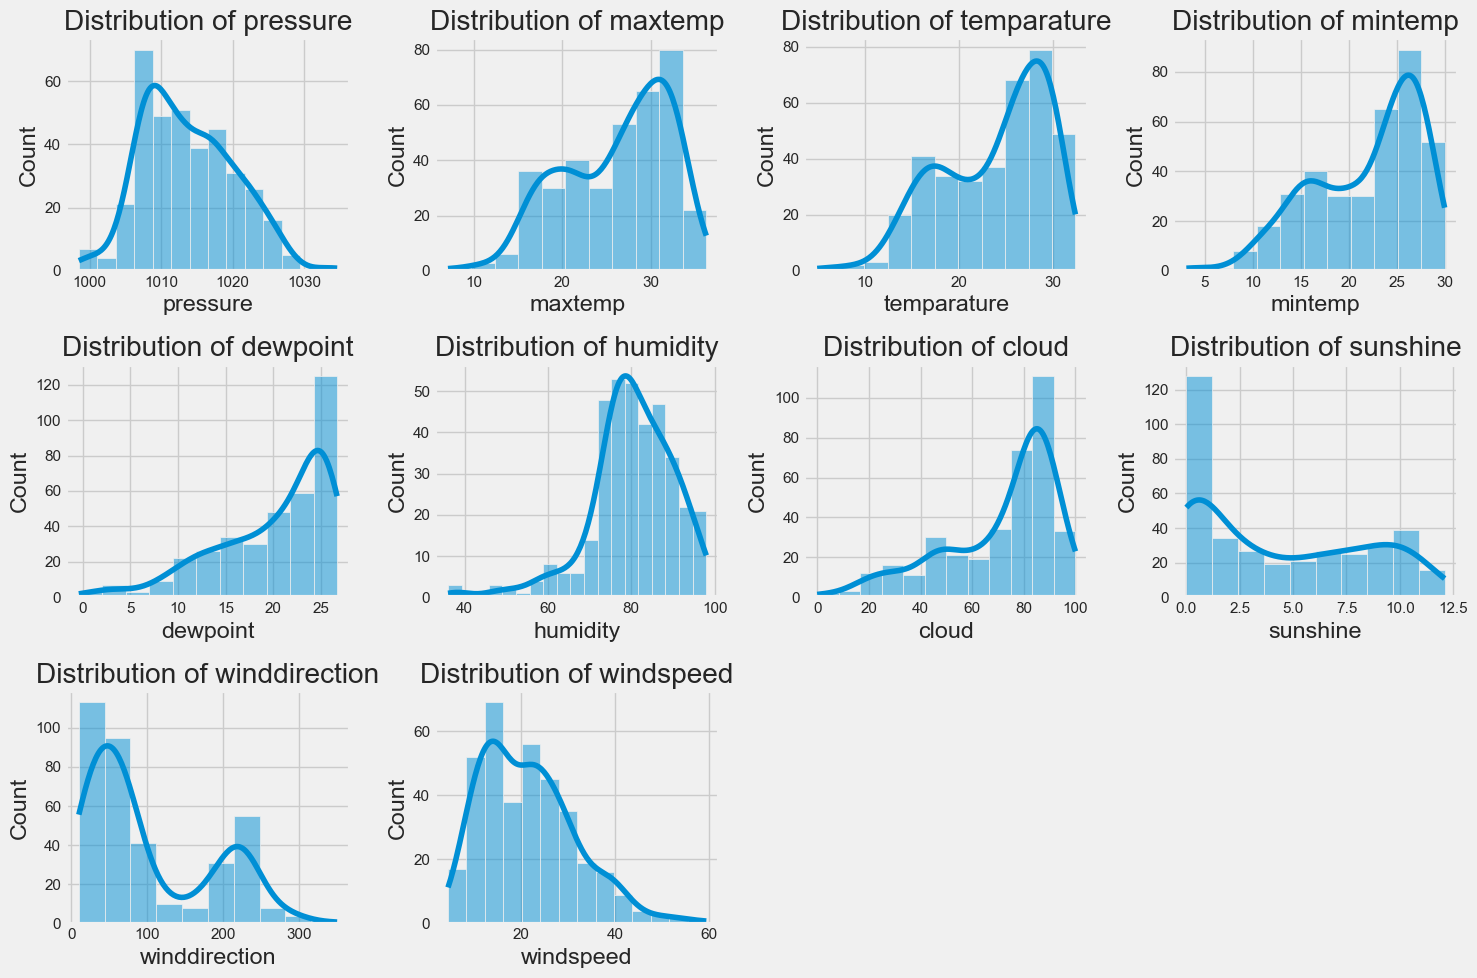

In [26]:
columns = ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed']

plt.figure(figsize = (15, 10))

for i, column in enumerate(columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], kde = True)
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

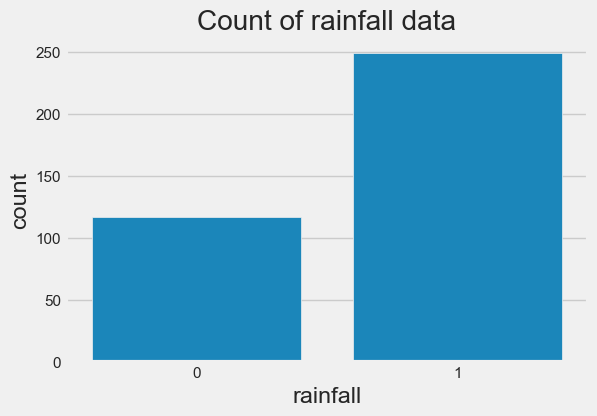

In [27]:
plt.figure(figsize = (6, 4))
sns.countplot(x = "rainfall", data = df)
plt.title("Count of rainfall data")
plt.show()

Handling missing value-> mode , mean
Categorical -> numerical , rainfall, map method
kde - > histplot
imbalance -> SMOTE (oversample, undersample)
Feature eng.-> corr
Outlier->boxplot

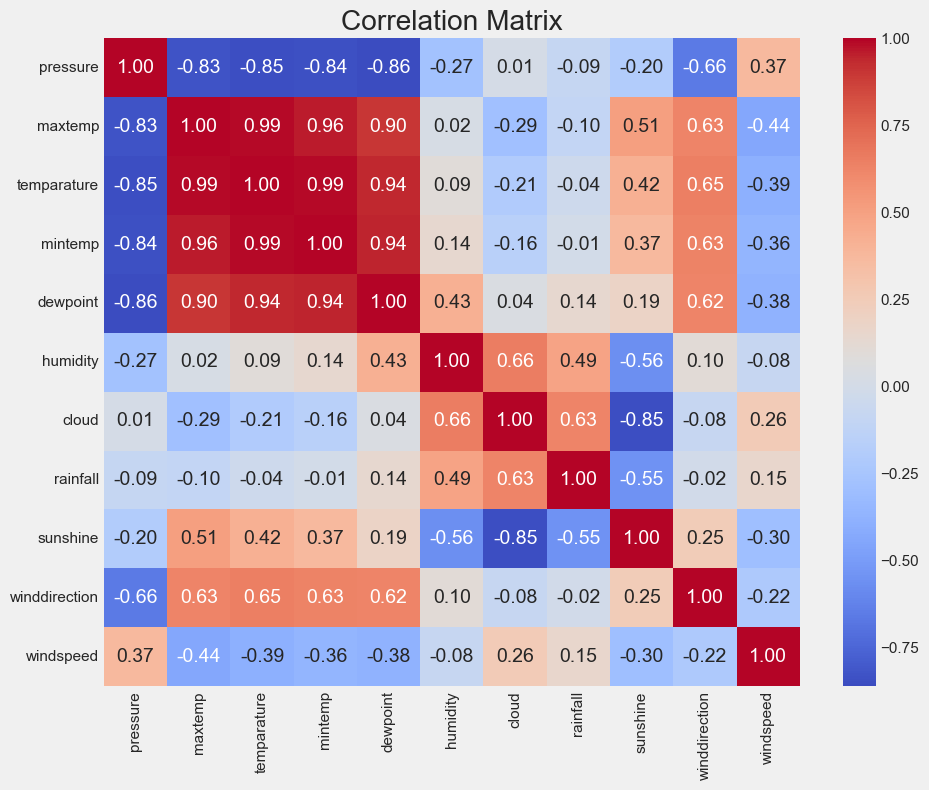

In [28]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot=True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

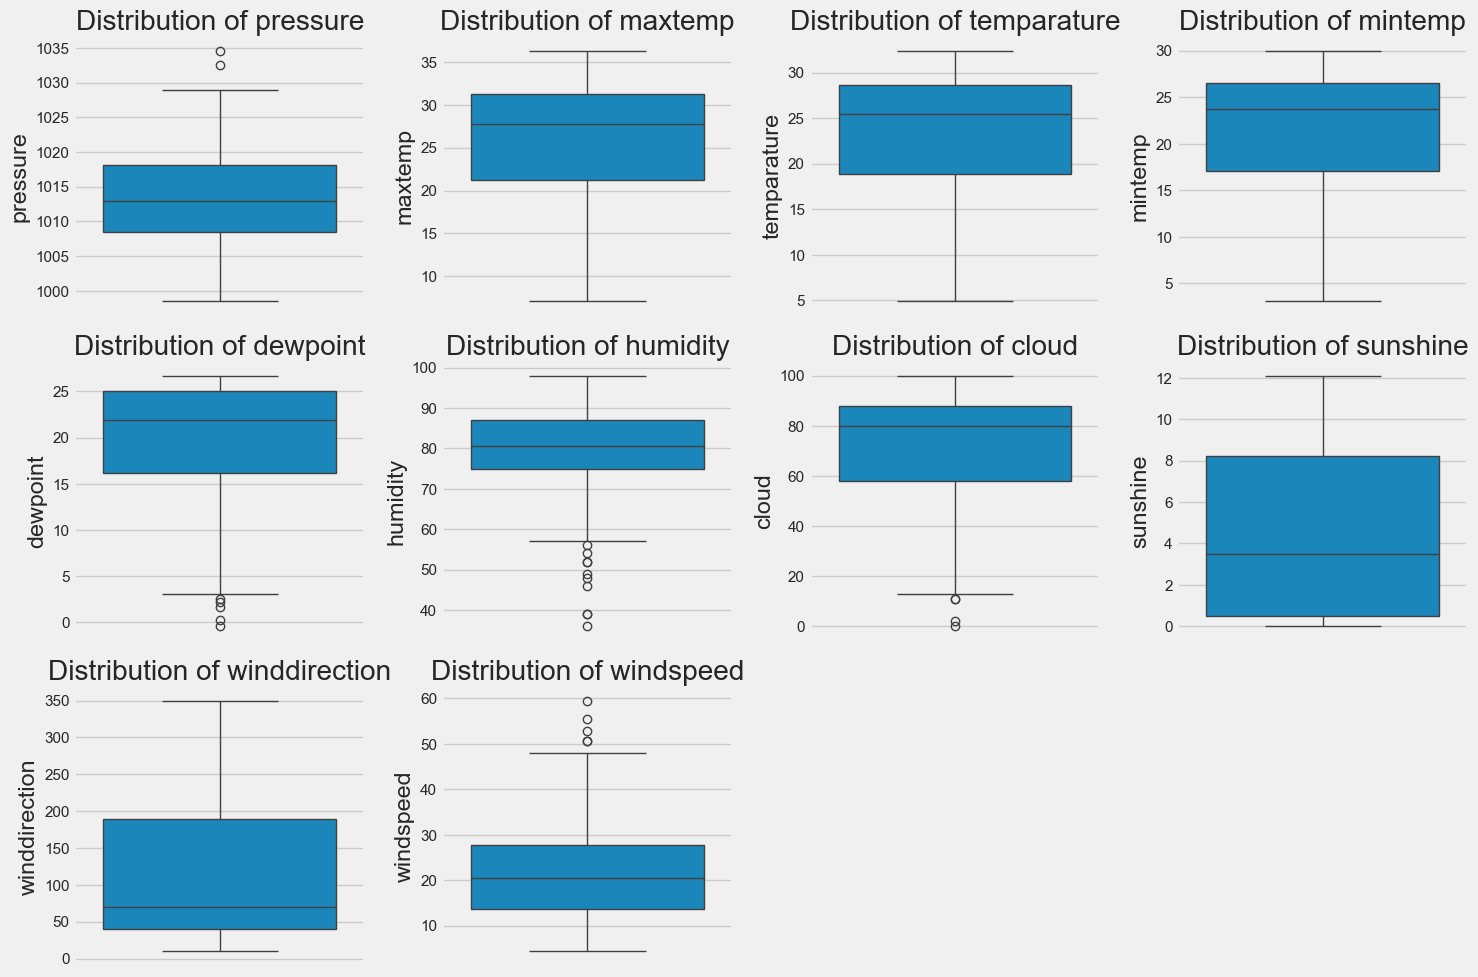

In [29]:
columns = ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed']

plt.figure(figsize = (15, 10))

for i, column in enumerate(columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(df[column])
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

In [30]:
df = df.drop(columns = ['maxtemp', 'temparature', 'mintemp'])

In [31]:
df.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [32]:
df.columns

Index(['pressure', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [33]:
df['rainfall'].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

In [34]:
df_majority = df[df['rainfall'] == 1]
df_minority = df[df['rainfall'] == 0]

In [35]:
downsample_indices = np.random.choice(df_majority.index, size = len(df_minority), replace=False)

In [36]:
df_majority_downsampled = df_majority.loc[downsample_indices]

In [37]:
df_majority_downsampled.shape

(117, 8)

In [38]:
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

In [39]:
df_downsampled = df_downsampled.sample(frac = 1, random_state = 42).reset_index(drop=True)

In [40]:
df_downsampled['rainfall'].value_counts()

rainfall
1    117
0    117
Name: count, dtype: int64

In [41]:
# Model Building
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [42]:
X = df_downsampled.drop(columns = ['rainfall'])
y = df_downsampled['rainfall']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [44]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [50, 100, 200], 
    "max_features":['sqrt', 'log2'],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [45]:
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv = 5, n_jobs = -1, verbose = 2)

In [46]:
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [47]:
best_rf_model = grid_search_rf.best_estimator_

In [48]:
grid_search_rf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 50}

In [49]:
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5)

In [50]:
np.mean(cv_scores)

np.float64(0.8082503556187767)

In [51]:
y_pred = best_rf_model.predict(X_test)

In [52]:
accuracy_score(y_test, y_pred)

0.7021276595744681

In [53]:
confusion_matrix(y_test, y_pred)

array([[16,  8],
       [ 6, 17]])

In [54]:
report_dict = classification_report(y_test, y_pred, output_dict = True)

In [55]:
report_dict

{'0': {'precision': 0.7272727272727273,
  'recall': 0.6666666666666666,
  'f1-score': 0.6956521739130435,
  'support': 24.0},
 '1': {'precision': 0.68,
  'recall': 0.7391304347826086,
  'f1-score': 0.7083333333333334,
  'support': 23.0},
 'accuracy': 0.7021276595744681,
 'macro avg': {'precision': 0.7036363636363636,
  'recall': 0.7028985507246377,
  'f1-score': 0.7019927536231885,
  'support': 47.0},
 'weighted avg': {'precision': 0.7041392649903288,
  'recall': 0.7021276595744681,
  'f1-score': 0.7018578476719087,
  'support': 47.0}}

Mishu-> DS -> Credit Card Fraud -> notebook 1, notebook 2, notebook 3
Ruby-> DS -> notebook 4, notebook 5, notebook 6
Boss -> 

MLFlow

In [57]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import mlflow
import mlflow.sklearn

In [59]:
report_dict

{'0': {'precision': 0.7272727272727273,
  'recall': 0.6666666666666666,
  'f1-score': 0.6956521739130435,
  'support': 24.0},
 '1': {'precision': 0.68,
  'recall': 0.7391304347826086,
  'f1-score': 0.7083333333333334,
  'support': 23.0},
 'accuracy': 0.7021276595744681,
 'macro avg': {'precision': 0.7036363636363636,
  'recall': 0.7028985507246377,
  'f1-score': 0.7019927536231885,
  'support': 47.0},
 'weighted avg': {'precision': 0.7041392649903288,
  'recall': 0.7021276595744681,
  'f1-score': 0.7018578476719087,
  'support': 47.0}}

In [62]:
mlflow.set_experiment('Rainfall1')
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000/")

with mlflow.start_run():
    mlflow.log_params(grid_search_rf.best_params_)
    mlflow.log_metrics({
        "accuracy":report_dict['accuracy'], 
        "recall_class_0":report_dict['0']['recall'],
        "recall_class_1":report_dict['1']['recall'],
        "f1_score_macro":report_dict['macro avg']['f1-score']
    })
    
    mlflow.sklearn.log_model(best_rf_model, "Random Forest Model Data")

2026/02/27 12:01:05 INFO mlflow.tracking.fluent: Experiment with name 'Rainfall1' does not exist. Creating a new experiment.
2026/02/27 12:01:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 12:01:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run amusing-gnu-657 at: http://127.0.0.1:5000/#/experiments/579786649119807123/runs/81f9232eb22047bcb4c5b3b978cbcc1a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/579786649119807123


In [63]:
model_name = "Random Forest Model Data"
run_id = "81f9232eb22047bcb4c5b3b978cbcc1a"
model_uri = f'runs:/{run_id}/{model_name}'

with mlflow.start_run(run_id = run_id):
    mlflow.register_model(model_uri=model_uri, name = model_name)

Successfully registered model 'Random Forest Model Data'.
2026/02/27 12:06:17 WARNING mlflow.tracking._model_registry.fluent: Run with id 81f9232eb22047bcb4c5b3b978cbcc1a has no artifacts at artifact path 'Random Forest Model Data', registering model based on models:/m-f6c4a7d5db444cda84f33301232b085b instead
2026/02/27 12:06:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Random Forest Model Data, version 1


🏃 View run amusing-gnu-657 at: http://127.0.0.1:5000/#/experiments/579786649119807123/runs/81f9232eb22047bcb4c5b3b978cbcc1a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/579786649119807123


Created version '1' of model 'Random Forest Model Data'.


In [64]:
import mlflow
logged_model = 'runs:/81f9232eb22047bcb4c5b3b978cbcc1a/Random Forest Model Data'

# Load model as a PyFuncModel.
loaded_model = mlflow.sklearn.load_model(logged_model)

loaded_model.predict(X_test)

array([1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1])

In [65]:
loaded_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [68]:
current_model_uri = f"models:/{model_name}@challenger"
production_model_name = 'rainfall-prediction-production'

client = mlflow.MlflowClient()
client.copy_model_version(src_model_uri=current_model_uri, dst_name=production_model_name)

Registered model 'rainfall-prediction-production' already exists. Creating a new version of this model...
Copied version '1' of model 'Random Forest Model Data' to version '2' of model 'rainfall-prediction-production'.


<ModelVersion: aliases=[], creation_timestamp=1772190924238, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1772190924238, metrics=None, model_id=None, name='rainfall-prediction-production', params=None, run_id='81f9232eb22047bcb4c5b3b978cbcc1a', run_link='', source='models:/Random Forest Model Data/1', status='READY', status_message=None, tags={}, user_id='', version='2', workspace='default'>

In [67]:
import mlflow
from mlflow.exceptions import MlflowException

# Project Configuration
model_name = "Random Forest Model Data"
production_model_name = "rainfall-prediction-production"
client = mlflow.MlflowClient()

try:
    # 1. Get the latest version number of the model
    # Usually, you want to promote the most recent version
    latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
    
    # 2. Assign the 'challenger' alias to that version
    # This fixes the "alias not found" error you saw
    client.set_registered_model_alias(
        name=model_name, 
        alias="challenger", 
        version=str(latest_version)
    )
    print(f"Assigned @challenger alias to {model_name} version {latest_version}")

    # 3. Define the URI using the alias
    current_model_uri = f"models:/{model_name}@challenger"

    # 4. Copy to the production model registry
    # This will create the 'rainfall-prediction-production' model if it doesn't exist
    client.copy_model_version(
        src_model_uri=current_model_uri, 
        dst_name=production_model_name
    )
    print(f"Successfully promoted {current_model_uri} to {production_model_name}")

except MlflowException as e:
    print(f"Error in MLflow Workflow: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

C:\Users\rubyb\AppData\Local\Temp\ipykernel_31564\4262762499.py:12: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version


Assigned @challenger alias to Random Forest Model Data version 1
Successfully promoted models:/Random Forest Model Data@challenger to rainfall-prediction-production


Successfully registered model 'rainfall-prediction-production'.
Copied version '1' of model 'Random Forest Model Data' to version '1' of model 'rainfall-prediction-production'.


In [70]:
import mlflow

# 1. Setup the client
client = mlflow.MlflowClient()
production_model_name = 'rainfall-prediction-production'

# 2. Assign the 'champion' alias to version 1 
# This tells MLflow that @champion points to model_version 1
client.set_registered_model_alias(
    name=production_model_name, 
    alias="champion", 
    version="1"
)

# 3. Now the URI will resolve correctly
prod_model_uri = f'models:/{production_model_name}@champion'

# 4. Load and predict
loaded_model = mlflow.sklearn.load_model(prod_model_uri)
y_pred = loaded_model.predict(X_test)

print("Model loaded successfully using @champion alias!")

Model loaded successfully using @champion alias!


In [71]:
model_version = 1
prod_model_uri = f'models:/{production_model_name}@champion'

loaded_model = mlflow.sklearn.load_model(prod_model_uri)
y_pred = loaded_model.predict(X_test)

In [72]:
y_pred

array([1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1])

In [73]:
# Predictive System
input_df = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)
input_df = pd.DataFrame([input_df], ['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'])

In [74]:
prediction = loaded_model.predict(input_df)

c:\Users\rubyb\Desktop\Rain-Fall-Prediction-using-Python-MLFlow\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [75]:
print("Prediction Result: ", "Rainfall" if prediction[0] == 1 else "No Rainfall")

Prediction Result:  Rainfall
